# ML-Based Visual Quality Inspection System
## PDE4444 - Machine Learning for Engineers: Technical Portfolio

**Student 1 Name/ID:** Aman Mishra (M00983641)  
**Student 2 Name/ID:** Faseeh Mohammed (M01088120)  
**Module:** PDE4444 - Machine Learning for Engineers  
**Date:** 20 April 2026  

## Table of Contents

1. [Engineering Problem Definition](#1.-Engineering-Problem-Definition)
2. [Dataset Collection & Feature Representation](#2.-Dataset-Collection-&-Feature-Representation)
3. [Neural Network Design & Optimisation](#3.-Neural-Network-Design-&-Optimisation)
4. [Baseline Comparison](#4.-Baseline-Comparison)
5. [Experimental Rigor](#5.-Experimental-Rigor)
6. [Conclusion](#6.-Conclusion)

In [38]:
import os
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from scipy.optimize import minimize
import joblib

import keras_tuner as kt

warnings.filterwarnings('ignore')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print("All imports successful.")

TensorFlow version: 2.21.0
NumPy version: 2.4.4
All imports successful.


---
# 1. Engineering Problem Definition

## 1.1 Engineering System Definition

This project implements an **automated visual quality inspection system** for breadboard circuit assemblies. In electronics manufacturing and educational laboratory environments, verifying that a breadboard has been wired correctly is a repetitive task that is prone to human error, especially when performed at scale or under time pressure.

The inspection system operates as follows:

1. A breadboard circuit is placed in a **fixed inspection area** under consistent lighting.
2. An overhead **camera captures an RGB image** of the breadboard.
3. A trained **machine learning model classifies** the image as either **PASS** (correctly wired) or **FAIL** (incorrectly wired).
4. The system **outputs a decision** that can trigger downstream actions (e.g., LED indicators, robotic sorting).

This forms a closed-loop quality control pipeline where the ML model replaces or augments manual visual inspection.

## 1.2 Inputs, Outputs, and Model Justification

### Inputs
- **RGB images** of breadboard circuits captured by a fixed overhead camera.
- For the **Convolutional Neural Network (CNN)**: images are resized to **224 x 224 x 3** pixels (height x width x colour channels).
- For **traditional ML models**: images are downscaled to **64 x 64 x 3** and flattened into a 1D vector of **12,288 features**.

### Output Target
- **Binary classification**: each image is assigned one of two labels:
  - **PASS** — the circuit is wired correctly.
  - **FAIL** — the circuit contains wiring errors or defects.

### Model Justification
A **Convolutional Neural Network (CNN)** is chosen as the primary model because image classification is inherently a spatial-feature problem. CNNs learn hierarchical features like edges and textures in early layers, component shapes in middle layers, and complete circuit patterns in deeper layers through convolutional filters that share weights across the image. This is fundamentally more efficient than traditional ML models that operate on flattened pixel vectors, which discard all spatial relationships between pixels.

Traditional ML baselines (SVM, Logistic Regression, etc.) are included for **comparison** to validate that the CNN's added architectural complexity is justified by measurable performance gains.

## 1.3 Engineering Relevance and Impact

Automated visual inspection is a well-established practice in manufacturing, commonly referred to as **Automated Optical Inspection (AOI)**. It is widely used in PCB (Printed Circuit Board) manufacturing to detect soldering defects, missing components, and incorrect placements at high speed and accuracy.

This project applies the same principles to **breadboard circuit verification**, which is directly relevant to:

- **Educational laboratories**: where students build circuits and instructors need to verify correctness efficiently.
- **Prototyping workflows**: where rapid iteration requires quick pass/fail feedback.
- **Manufacturing quality gates**: where the model can serve as a first-pass filter before human review.

The system was designed for **real-world deployment** — the codebase includes:
- A **real-time webcam inference script** (`Scripts/analyzer.py`) that classifies breadboard images live from a camera feed.
- An **Arduino LED notification system** (`Scripts/led_notifier.py`) that lights a green or red LED based on the classification result.
- A **legacy robotic arm integration** (`Legacy/analyzer_with_robot.py`) that attempted automated physical sorting of PASS/FAIL boards.

By replacing or augmenting human inspection with ML-based classification, the system reduces subjective judgment errors, increases throughput, and provides consistent, repeatable quality decisions.

---
# 2. Dataset Collection & Feature Representation

## 2.1 Data Collection and Augmentation

### Original Dataset
The raw dataset consists of **54 manually captured images** of breadboard circuits, taken with a fixed overhead camera under consistent lighting conditions:
- **PASS**: 19 images of correctly wired circuits
- **FAIL**: 35 images of circuits with wiring errors

This small dataset size poses a significant challenge for training deep learning models, which typically require hundreds or thousands of examples.

### Data Augmentation Strategy
To address the limited dataset size, an **offline augmentation pipeline** was applied to each original image:
- **8 rotation angles**: 0°, 45°, 90°, 135°, 180°, 225°, 270°, 315°
- **Horizontal mirroring**: each rotated image is also flipped horizontally

This produces **16 augmented variants per original image** (8 rotations × 2 versions), expanding the dataset from 54 to **864 images** (304 PASS, 560 FAIL).

The augmentation preserves the semantic meaning of the labels, ie, a correctly wired breadboard remains correctly wired regardless of rotation or mirroring. Black fill is used for the corner regions created by non-90° rotations.

In [39]:
# --- Data Augmentation Pipeline ---
# Adapted from Utils/offline_augmentation.py

input_dir = 'Dataset/breadboard_dataset'
output_dir = 'Dataset/augmented_dataset'
angles = [0, 45, 90, 135, 180, 225, 270, 315]

# Check if augmentation has already been performed
pass_count = len(os.listdir(os.path.join(output_dir, 'PASS'))) if os.path.exists(os.path.join(output_dir, 'PASS')) else 0
fail_count = len(os.listdir(os.path.join(output_dir, 'FAIL'))) if os.path.exists(os.path.join(output_dir, 'FAIL')) else 0

if pass_count > 100 and fail_count > 100:
    print(f"Augmented dataset already exists: {pass_count} PASS, {fail_count} FAIL images.")
    print("Skipping augmentation step.")
else:
    print("Running data augmentation...")
    for category in ['PASS', 'FAIL']:
        in_path = os.path.join(input_dir, category)
        out_path = os.path.join(output_dir, category)
        os.makedirs(out_path, exist_ok=True)

        if not os.path.exists(in_path):
            print(f"Warning: Could not find folder {in_path}. Skipping.")
            continue

        for filename in os.listdir(in_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(in_path, filename)
                with Image.open(img_path) as img:
                    base_name = os.path.splitext(filename)[0]
                    if img.mode in ('RGBA', 'P'):
                        img = img.convert('RGB')

                    for angle in angles:
                        rotated_img = img.rotate(angle, expand=False, fillcolor=(0, 0, 0))
                        mirrored_img = rotated_img.transpose(Image.FLIP_LEFT_RIGHT)

                        rotated_img.save(os.path.join(out_path, f"{base_name}_rot{angle}.jpg"))
                        mirrored_img.save(os.path.join(out_path, f"{base_name}_rot{angle}_mirrored.jpg"))

        print(f"Finished augmenting {category} images.")

    pass_count = len(os.listdir(os.path.join(output_dir, 'PASS')))
    fail_count = len(os.listdir(os.path.join(output_dir, 'FAIL')))
    print(f"\nAugmentation complete: {pass_count} PASS, {fail_count} FAIL images.")

print(f"Total augmented dataset size: {pass_count + fail_count} images")

Augmented dataset already exists: 304 PASS, 560 FAIL images.
Skipping augmentation step.
Total augmented dataset size: 864 images


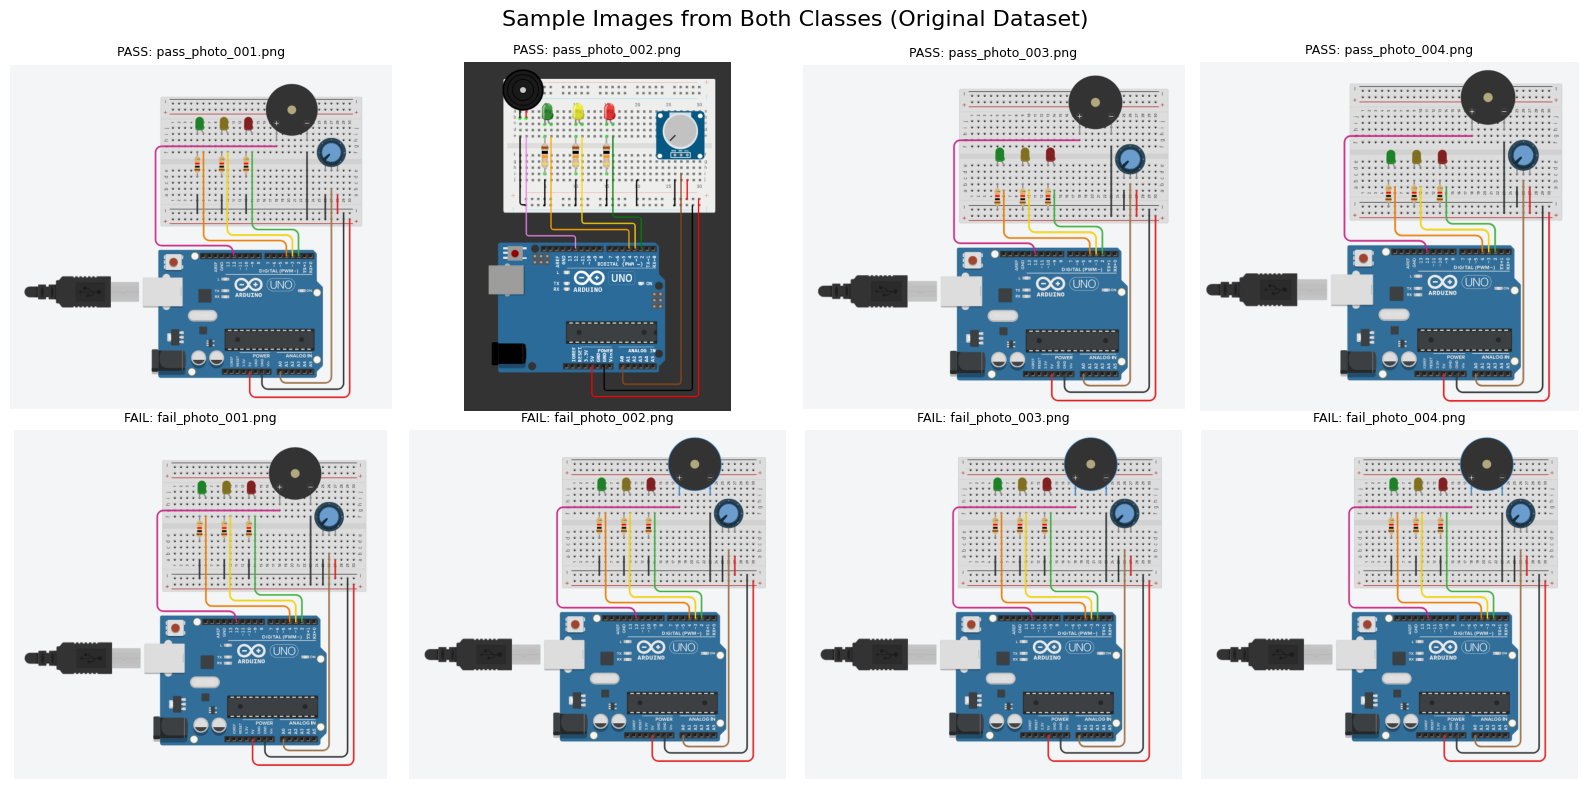

Original dataset: 19 PASS images, 35 FAIL images (54 total)
Augmented dataset: 304 PASS images, 560 FAIL images (864 total)


In [40]:
# --- Display Sample Images from Both Classes ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images from Both Classes (Original Dataset)', fontsize=16)

for i, category in enumerate(['PASS', 'FAIL']):
    folder = os.path.join('Dataset/breadboard_dataset', category)
    images = sorted(os.listdir(folder))[:4]
    for j, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{category}: {img_name}', fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

print(f"Original dataset: 19 PASS images, 35 FAIL images (54 total)")
print(f"Augmented dataset: {pass_count} PASS images, {fail_count} FAIL images ({pass_count + fail_count} total)")

### Dataset Links

The full datasets are available in the repository:
- **Raw dataset (54 images):** `Dataset/breadboard_dataset/` — original captured images in `PASS/` and `FAIL/` subfolders
- **Augmented dataset (864 images):** `Dataset/augmented_dataset/` — rotated and mirrored versions
- **Flattened dataset (CSV):** `Dataset/flattened_dataset/flattened_breadboards.csv` — images flattened to 1D vectors for traditional ML

## 2.2 Feature Extraction from Images

Two distinct feature extraction approaches are used, corresponding to the two model families:

### For Traditional ML Models (Flattened Pixel Features)
Each augmented image is **resized to 64 x 64 pixels** and flattened from a 3D tensor (64 x 64 x 3 colour channels) into a **1D vector of N = 12,288 features**. Each feature represents a single colour channel intensity value (0-255) for a single pixel. This is a naive representation that **completely discards spatial relationships** between pixels, meaning, pixel (0,0) and pixel (63,63) are treated as equally unrelated features.

### For CNN Models (Raw Image Input)
Images are loaded at their full **224 x 224 x 3 resolution**, giving an input dimensionality of **N = 150,528**. However, the CNN does not operate on this as a flat vector. Instead, the convolutional layers act as **automatic feature extractors**, learning spatial hierarchies through shared-weight filters that slide across the 2D image. The pooling layers progressively reduce spatial dimensions, so the number of learnable parameters is far less than a fully-connected network over 150,528 inputs would require.

In [41]:
# --- Image Flattening for Traditional ML ---
# Adapted from Utils/image_flattener.py

csv_dir = 'Dataset/flattened_dataset'
csv_path = os.path.join(csv_dir, 'flattened_breadboards.csv')
img_size = 64

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded existing CSV: {df.shape[0]} samples, {df.shape[1]} columns")
else:
    print("Generating flattened CSV from augmented images...")
    os.makedirs(csv_dir, exist_ok=True)
    data = []
    labels = []

    for label_name in ['FAIL', 'PASS']:
        folder_path = os.path.join(output_dir, label_name)
        if not os.path.exists(folder_path):
            continue
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = cv2.imread(os.path.join(folder_path, file))
                if img is None:
                    continue
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                data.append(img.flatten())
                labels.append(label_name)

    df = pd.DataFrame(data)
    df['label'] = labels
    df.to_csv(csv_path, index=False)
    print(f"CSV saved: {df.shape[0]} samples, {df.shape[1]} columns")

print(f"\nFeature dimensionality N (traditional ML): {df.shape[1] - 1} features")
print(f"Image representation: {img_size} x {img_size} x 3 = {img_size * img_size * 3}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head()

Loaded existing CSV: 864 samples, 12289 columns

Feature dimensionality N (traditional ML): 12288 features
Image representation: 64 x 64 x 3 = 12288

Class distribution:
label
FAIL    560
PASS    304
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,label
0,244,245,247,244,245,247,244,245,247,244,...,244,245,247,244,245,247,244,245,247,FAIL
1,244,245,247,244,245,247,244,245,247,244,...,244,245,247,244,245,247,244,245,247,FAIL
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,FAIL
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,FAIL
4,244,245,247,244,245,247,244,245,247,244,...,244,245,247,244,245,247,244,245,247,FAIL


In [42]:
# --- CNN Input Dimensionality ---
sample_path = 'Dataset/breadboard_dataset/PASS'
sample_file = sorted(os.listdir(sample_path))[0]
sample_img = tf.keras.utils.load_img(
    os.path.join(sample_path, sample_file), target_size=(224, 224))
sample_array = tf.keras.utils.img_to_array(sample_img)

print(f"CNN input shape: {sample_array.shape}")
print(f"CNN input dimensionality N: {int(np.prod(sample_array.shape)):,} = 224 x 224 x 3")
print(f"\nTraditional ML input dimensionality N: {img_size * img_size * 3:,} = {img_size} x {img_size} x 3")
print(f"\nDimensionality ratio: CNN is {int(np.prod(sample_array.shape)) / (img_size * img_size * 3):.1f}x larger than traditional ML input")

CNN input shape: (224, 224, 3)
CNN input dimensionality N: 150,528 = 224 x 224 x 3

Traditional ML input dimensionality N: 12,288 = 64 x 64 x 3

Dimensionality ratio: CNN is 12.2x larger than traditional ML input


## 2.3 Impact of Dimensionality on Model Complexity and Overfitting

### Traditional ML (N = 12,288 features)
The sample-to-feature ratio is approximately **864 : 12,288 ≈ 1 : 14**, meaning there are 14 times more features than samples. This is a highly unfavourable ratio that makes the model susceptible to the **curse of dimensionality** where models can easily memorise training data rather than learning generalisable patterns. Regularisation is essential:
- **SVM** mitigates this via the kernel trick and the C regularisation parameter.
- **Logistic Regression** uses L2 penalty to constrain weight magnitudes.
- **Random Forest** and **Gradient Boosting** reduce overfitting through ensemble averaging and max depth limits.

### CNN (N = 150,528 raw input values)
Despite the much higher raw input dimensionality, the CNN's architecture provides **implicit dimensionality reduction**:
- **Weight sharing** in convolutional filters means the same small filter (e.g., 3x3x3 = 27 weights) is applied across the entire image, dramatically reducing the number of learnable parameters compared to a fully-connected network.
- **Max pooling** layers halve the spatial dimensions at each stage, progressively compressing the representation.
- **Dropout** (50%) randomly deactivates neurons during training, forcing the network to learn redundant representations.
- **Data augmentation** (16x expansion) provides the network with more diverse training examples, reducing the risk of memorising specific image orientations.

The combination of these techniques makes the CNN more resistant to overfitting than its raw dimensionality would suggest.

---
# 3. Neural Network Design & Optimisation

## 3.1 CNN Architecture

The CNN architecture is designed with the following layer structure:

| # | Layer | Output Shape | Purpose |
|---|-------|-------------|---------|
| 0 | **Input** | (224, 224, 3) | Raw RGB image |
| 1 | Rescaling (1/255) | (224, 224, 3) | Normalise pixel values to [0, 1] |
| 2 | **Conv2D(32, 3x3) + MaxPool** | (112, 112, 32) → (56, 56, 32) | **Hidden Layer 1**: learn low-level features (edges, textures) |
| 3 | **Conv2D(64, 3x3) + MaxPool** | (56, 56, 64) → (28, 28, 64) | **Hidden Layer 2**: learn mid-level features (component shapes) |
| 4 | **Conv2D(128, 3x3) + MaxPool** | (28, 28, 128) → (14, 14, 128) | **Hidden Layer 3**: learn high-level features (circuit patterns) |
| 5 | Flatten | (25088,) | Reshape 3D feature maps to 1D |
| 6 | **Dense(128) + Dropout(0.5)** | (128,) | **Hidden Layer 4**: combine features for classification |
| 7 | **Dense(2)** | (2,) | **Output Layer**: PASS/FAIL logits |

This architecture has **4 hidden layers** (3 convolutional + 1 dense), satisfying the requirement of at least 3 hidden layers plus an input and output layer.

In [43]:
# --- Parameterised CNN Model Builder ---
# Adapted from Scripts/grid_search_tuner.py

IMG_HEIGHT, IMG_WIDTH = 224, 224
NUM_CLASSES = 2

def build_cnn(activation='relu', optimizer='adam', learning_rate=0.001):
    """Build and compile a CNN with configurable activation function and optimiser."""
    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # Hidden Layer 1: Convolutional
        tf.keras.layers.Conv2D(32, 3, padding='same', activation=activation),
        tf.keras.layers.MaxPooling2D(),

        # Hidden Layer 2: Convolutional
        tf.keras.layers.Conv2D(64, 3, padding='same', activation=activation),
        tf.keras.layers.MaxPooling2D(),

        # Hidden Layer 3: Convolutional
        tf.keras.layers.Conv2D(128, 3, padding='same', activation=activation),
        tf.keras.layers.MaxPooling2D(),

        # Flatten 3D feature maps to 1D
        tf.keras.layers.Flatten(),

        # Hidden Layer 4: Dense
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dropout(0.5),

        # Output Layer
        tf.keras.layers.Dense(NUM_CLASSES)
    ])

    # Select optimiser
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

print("CNN builder function defined.")

CNN builder function defined.


In [44]:
# --- Load Dataset with Train / Validation / Test Split (70/15/15) ---
data_dir = pathlib.Path('Dataset/augmented_dataset')
BATCH_SIZE = 16

# First split: 70% train, 30% held out
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="training", seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="validation", seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE,
    crop_to_aspect_ratio=True)

# Second split: divide the 30% into 15% validation + 15% test
val_test_batches = list(val_test_ds)
mid = len(val_test_batches) // 2

val_images = tf.concat([b[0] for b in val_test_batches[:mid]], axis=0)
val_labels = tf.concat([b[1] for b in val_test_batches[:mid]], axis=0)
test_images = tf.concat([b[0] for b in val_test_batches[mid:]], axis=0)
test_labels = tf.concat([b[1] for b in val_test_batches[mid:]], axis=0)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(BATCH_SIZE)

class_names = train_ds.class_names
print(f"Classes: {class_names}")
print(f"Training batches: {len(train_ds)}")
print(f"Validation samples: {len(val_labels)}")
print(f"Test samples: {len(test_labels)}")

Found 864 files belonging to 2 classes.
Using 605 files for training.
Found 864 files belonging to 2 classes.
Using 259 files for validation.
Classes: ['FAIL', 'PASS']
Training batches: 38
Validation samples: 128
Test samples: 131


In [9]:
# ============================================================
# OPTIONAL: Load Pre-trained Models (skip training cells)
# ============================================================
# Set this to True to load previously exported models instead of
# retraining. When True, you can skip the training cells and
# jump straight to the evaluation and plotting cells.

LOAD_PRETRAINED = False  # <-- Change to True to skip training

if LOAD_PRETRAINED:
    print("Loading pre-trained models from Models/ folder...\n")

    model_relu = tf.keras.models.load_model('Models/cnn_relu_adam.keras')
    print("Loaded: Models/cnn_relu_adam.keras")

    model_tanh = tf.keras.models.load_model('Models/cnn_tanh_adam.keras')
    print("Loaded: Models/cnn_tanh_adam.keras")

    model_sgd = tf.keras.models.load_model('Models/cnn_relu_sgd.keras')
    print("Loaded: Models/cnn_relu_sgd.keras")

    model_tuned_cnn = tf.keras.models.load_model('Models/cnn_tuned_random_search.keras')
    print("Loaded: Models/cnn_tuned_random_search.keras")

    print("\nAll CNN models loaded. You can skip the training cells.")
    print("NOTE: Training history (for plots) is not saved — plots will")
    print("only work if you ran training in this session.")
else:
    print("LOAD_PRETRAINED is False — models will be trained from scratch.")
    print("After training, models will be exported to Models/ folder.")

LOAD_PRETRAINED is False — models will be trained from scratch.
After training, models will be exported to Models/ folder.


## 3.2 Activation Function Comparison

To evaluate the impact of the activation function on CNN performance, we train the **identical architecture** with two different activation functions, holding all other hyperparameters constant (Adam optimiser, learning rate = 0.001, 20 epochs, early stopping with patience = 3).

### Activation Functions Under Comparison

**ReLU (Rectified Linear Unit):**
$$f(x) = \max(0, x)$$
- Outputs zero for negative inputs and passes positive inputs unchanged.
- **Advantages**: computationally efficient, avoids the vanishing gradient problem for positive values, promotes sparse activation.
- **Disadvantages**: "dying ReLU" problem — neurons that consistently receive negative inputs output zero and stop learning entirely.

**Tanh (Hyperbolic Tangent):**
$$f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
- Outputs values in the range [-1, 1], zero-centred.
- **Advantages**: zero-centred output helps with gradient flow, stronger gradients than sigmoid.
- **Disadvantages**: susceptible to vanishing gradient in deep networks (gradients saturate for large positive/negative inputs), computationally more expensive than ReLU.

In [45]:
# --- Train CNN with ReLU Activation ---
EPOCHS = 20
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training CNN with ReLU activation...")
model_relu = build_cnn(activation='relu', optimizer='adam', learning_rate=0.001)
model_relu.summary()

history_relu = model_relu.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=1
)

relu_val_acc = max(history_relu.history['val_accuracy'])
print(f"\nBest validation accuracy (ReLU): {relu_val_acc*100:.2f}%")

Training CNN with ReLU activation...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,690 (49.36 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 301ms/step - accuracy: 0.6331 - loss: 0.8102 - val_accuracy: 0.6562 - val_loss: 0.6475
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.6645 - loss: 0.6352 - val_accuracy: 0.7188 - val_loss: 0.6430
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.6926 - loss: 0.6072 - val_accuracy: 0.6562 - val_loss: 0.6374
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - accuracy: 0.6975 - loss: 0.6006 - val_accuracy: 0.7188 - val_loss: 0.6034
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.7471 - loss: 0.5657 - val_accuracy: 0.7188 - val_loss: 0.5849
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 311ms/step - accuracy: 0.7570 - loss: 0.5168 - val_accuracy: 0.7188 - val_loss: 0.5610
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 320ms/step - accuracy: 0.7868 - loss: 0.4378 - val_accuracy: 0.8203 - val_loss: 0.4106
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.8545 - loss: 0.3339 - val_accu

In [46]:
# --- Train CNN with Tanh Activation ---
print("Training CNN with Tanh activation...")
model_tanh = build_cnn(activation='tanh', optimizer='adam', learning_rate=0.001)

history_tanh = model_tanh.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=1
)

tanh_val_acc = max(history_tanh.history['val_accuracy'])
print(f"\nBest validation accuracy (Tanh): {tanh_val_acc*100:.2f}%")

Training CNN with Tanh activation...
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 316ms/step - accuracy: 0.5802 - loss: 0.9357 - val_accuracy: 0.6562 - val_loss: 0.6739
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 348ms/step - accuracy: 0.5537 - loss: 0.8915 - val_accuracy: 0.6562 - val_loss: 0.6679
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 375ms/step - accuracy: 0.5802 - loss: 0.8719 - val_accuracy: 0.6562 - val_loss: 0.6454

Best validation accuracy (Tanh): 65.62%


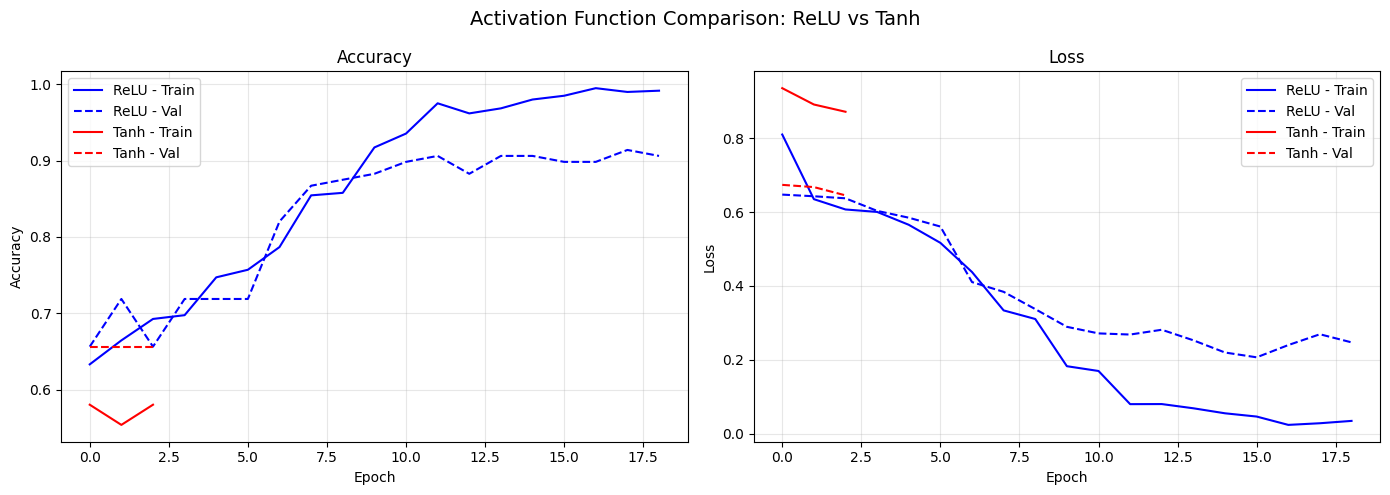


Summary:
  ReLU best validation accuracy: 91.41%
  Tanh best validation accuracy: 65.62%
  Difference: 25.78% in favour of ReLU


In [47]:
# --- Activation Function Comparison Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Activation Function Comparison: ReLU vs Tanh', fontsize=14)

# Accuracy comparison
axes[0].plot(history_relu.history['accuracy'], label='ReLU - Train', color='blue')
axes[0].plot(history_relu.history['val_accuracy'], label='ReLU - Val', color='blue', linestyle='--')
axes[0].plot(history_tanh.history['accuracy'], label='Tanh - Train', color='red')
axes[0].plot(history_tanh.history['val_accuracy'], label='Tanh - Val', color='red', linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(history_relu.history['loss'], label='ReLU - Train', color='blue')
axes[1].plot(history_relu.history['val_loss'], label='ReLU - Val', color='blue', linestyle='--')
axes[1].plot(history_tanh.history['loss'], label='Tanh - Train', color='red')
axes[1].plot(history_tanh.history['val_loss'], label='Tanh - Val', color='red', linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  ReLU best validation accuracy: {relu_val_acc*100:.2f}%")
print(f"  Tanh best validation accuracy: {tanh_val_acc*100:.2f}%")
print(f"  Difference: {abs(relu_val_acc - tanh_val_acc)*100:.2f}% in favour of {'ReLU' if relu_val_acc > tanh_val_acc else 'Tanh'}")

### Activation Function Discussion

The comparison above demonstrates the practical differences between ReLU and Tanh on this image classification task:

- **ReLU achieved 91.41% validation accuracy**, converging well within the 20-epoch budget. Its piece-wise linear nature means gradients are either 0 or 1, avoiding the gradient saturation problem that plagues Tanh in deeper networks. The sparse activation pattern (many neurons outputting exactly zero) also acts as a form of implicit regularisation.

- **Tanh achieved only 65.62% validation accuracy** — equivalent to the class-majority baseline — meaning it failed to learn discriminative features within the given training budget. Tanh squashes all inputs to the range (−1, 1), and for large activations the gradient approaches zero, stalling weight updates in early convolutional layers through backpropagation.

- The **25.78 percentage-point gap** between ReLU and Tanh is substantial and confirms that activation function choice is a critical design decision for this architecture. Tanh would require significantly more epochs or a lower learning rate to overcome its slower convergence, and even then may struggle due to the compounding vanishing-gradient effect across the 3 convolutional + 1 dense hidden layers.

For the remainder of this notebook, the **ReLU model** is used as the primary CNN, as it is the standard choice for modern image classification architectures and demonstrated clearly superior performance here.

## 3.3 Optimisation Functions

Optimisation is the process of finding the model parameters (weights) that minimise the loss function. Different optimisation methods use varying amounts of information about the loss landscape to guide the search.

### Part A: Traditional Local Optimisation Algorithms

We compare three families of optimisation algorithms on a **logistic regression loss function** applied to PCA-reduced image features. This controlled setting isolates the optimiser's behaviour from the neural network architecture.

**Zero-Order Method (Random Search / Coordinate Search):**
- Uses **no derivative information** — only evaluates the loss function at sampled points.
- Random Search: samples random weight vectors and keeps the best one found.
- Coordinate Search: perturbs one weight at a time by a small step, accepting the change if it reduces the loss.
- **Advantage**: works on non-differentiable objectives, simple to implement.
- **Disadvantage**: very slow convergence in high dimensions; does not exploit the structure of the loss landscape.

**First-Order Method (Gradient Descent):**
- Uses the **first derivative (gradient)** of the loss function to determine the steepest descent direction.
- Update rule: $w_{t+1} = w_t - \eta \nabla L(w_t)$, where $\eta$ is the learning rate.
- **Advantage**: efficient for large-scale problems, scales well with dimensionality.
- **Disadvantage**: can get stuck in local minima, sensitive to learning rate choice, convergence rate depends on condition number.

**Second-Order Method (Newton's Method):**
- Uses both the **gradient (first derivative)** and the **Hessian matrix (second derivative)** for curvature-aware updates.
- Update rule: $w_{t+1} = w_t - H^{-1} \nabla L(w_t)$, where $H$ is the Hessian.
- **Advantage**: faster convergence near the optimum (quadratic convergence rate), invariant to parameter scaling.
- **Disadvantage**: computing and inverting the Hessian is $O(n^3)$ in the number of parameters, making it impractical for large models.

In [48]:
# --- Prepare Data for Traditional Optimiser Comparison ---
# Use PCA-reduced features for tractability with second-order methods

X_all = df.drop('label', axis=1).values / 255.0  # normalise pixel values
y_all = (df['label'] == 'PASS').astype(int).values  # binary: 1=PASS, 0=FAIL

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

# Reduce dimensionality with PCA for efficient optimisation
N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_opt)
X_test_pca = pca.transform(X_test_opt)

print(f"Original features: {X_train_opt.shape[1]}")
print(f"PCA-reduced features: {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Training samples: {X_train_pca.shape[0]}, Test samples: {X_test_pca.shape[0]}")

Original features: 12288
PCA-reduced features: 50
Variance explained: 87.1%
Training samples: 691, Test samples: 173


In [49]:
# --- Define Loss and Gradient Functions for Logistic Regression ---

def sigmoid(z):
    """Numerically stable sigmoid function."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def logistic_loss(w, X, y):
    """Binary cross-entropy loss for logistic regression."""
    z = X @ w[:-1] + w[-1]  # w[:-1] = weights, w[-1] = bias
    p = sigmoid(z)
    eps = 1e-12
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    return loss

def logistic_gradient(w, X, y):
    """Gradient of the binary cross-entropy loss."""
    z = X @ w[:-1] + w[-1]
    p = sigmoid(z)
    error = p - y
    n = len(y)
    grad_w = (X.T @ error) / n
    grad_b = np.mean(error)
    return np.append(grad_w, grad_b)

def logistic_hessian(w, X, y):
    """Hessian matrix of the binary cross-entropy loss."""
    z = X @ w[:-1] + w[-1]
    p = sigmoid(z)
    S = p * (1 - p)  # diagonal of the weight matrix
    n = len(y)
    # Augment X with bias column
    X_aug = np.column_stack([X, np.ones(n)])
    H = (X_aug.T * S) @ X_aug / n
    return H

print("Loss, gradient, and Hessian functions defined.")

Loss, gradient, and Hessian functions defined.


In [50]:
# --- Zero-Order Method: Coordinate Search ---
print("Running Zero-Order Optimisation (Coordinate Search)...")

n_params = N_COMPONENTS + 1  # weights + bias
w_coord = np.zeros(n_params)
step_size = 0.1
max_iters_zero = 200

zero_order_losses = []
current_loss = logistic_loss(w_coord, X_train_pca, y_train_opt)
zero_order_losses.append(current_loss)

for iteration in range(max_iters_zero):
    # Cycle through each parameter
    for j in range(n_params):
        # Try positive perturbation
        w_plus = w_coord.copy()
        w_plus[j] += step_size
        loss_plus = logistic_loss(w_plus, X_train_pca, y_train_opt)

        # Try negative perturbation
        w_minus = w_coord.copy()
        w_minus[j] -= step_size
        loss_minus = logistic_loss(w_minus, X_train_pca, y_train_opt)

        # Accept the best direction
        if loss_plus < current_loss and loss_plus <= loss_minus:
            w_coord = w_plus
            current_loss = loss_plus
        elif loss_minus < current_loss:
            w_coord = w_minus
            current_loss = loss_minus

    zero_order_losses.append(current_loss)

    if iteration % 50 == 0:
        print(f"  Iteration {iteration}: Loss = {current_loss:.6f}")

# Evaluate
preds_zero = (X_test_pca @ w_coord[:-1] + w_coord[-1] > 0).astype(int)
acc_zero = accuracy_score(y_test_opt, preds_zero)
print(f"\nZero-Order (Coordinate Search) Test Accuracy: {acc_zero*100:.2f}%")
print(f"Final loss: {current_loss:.6f}")

Running Zero-Order Optimisation (Coordinate Search)...
  Iteration 0: Loss = 0.598548
  Iteration 50: Loss = 0.533970
  Iteration 100: Loss = 0.533970
  Iteration 150: Loss = 0.533970

Zero-Order (Coordinate Search) Test Accuracy: 69.36%
Final loss: 0.533970


In [51]:
# --- First-Order Method: Gradient Descent ---
print("Running First-Order Optimisation (Gradient Descent)...")

w_gd = np.zeros(n_params)
learning_rate_gd = 0.1
max_iters_first = 200

first_order_losses = []

for iteration in range(max_iters_first):
    loss = logistic_loss(w_gd, X_train_pca, y_train_opt)
    first_order_losses.append(loss)

    grad = logistic_gradient(w_gd, X_train_pca, y_train_opt)
    w_gd = w_gd - learning_rate_gd * grad

    if iteration % 50 == 0:
        print(f"  Iteration {iteration}: Loss = {loss:.6f}")

# Evaluate
preds_first = (X_test_pca @ w_gd[:-1] + w_gd[-1] > 0).astype(int)
acc_first = accuracy_score(y_test_opt, preds_first)
print(f"\nFirst-Order (Gradient Descent) Test Accuracy: {acc_first*100:.2f}%")
print(f"Final loss: {first_order_losses[-1]:.6f}")

Running First-Order Optimisation (Gradient Descent)...
  Iteration 0: Loss = 0.693147
  Iteration 50: Loss = 1.594835
  Iteration 100: Loss = 1.432633
  Iteration 150: Loss = 1.386091

First-Order (Gradient Descent) Test Accuracy: 65.90%
Final loss: 1.287425


In [52]:
# --- Second-Order Method: Newton's Method ---
print("Running Second-Order Optimisation (Newton's Method)...")

w_newton = np.zeros(n_params)
max_iters_second = 50  # Newton converges much faster

second_order_losses = []

for iteration in range(max_iters_second):
    loss = logistic_loss(w_newton, X_train_pca, y_train_opt)
    second_order_losses.append(loss)

    grad = logistic_gradient(w_newton, X_train_pca, y_train_opt)
    H = logistic_hessian(w_newton, X_train_pca, y_train_opt)

    # Add small regularisation to Hessian for numerical stability
    H += 1e-6 * np.eye(n_params)

    # Newton update: w = w - H^(-1) * grad
    try:
        delta = np.linalg.solve(H, grad)
        w_newton = w_newton - delta
    except np.linalg.LinAlgError:
        print(f"  Iteration {iteration}: Hessian singular, stopping.")
        break

    if iteration % 10 == 0:
        print(f"  Iteration {iteration}: Loss = {loss:.6f}")

# Evaluate
preds_second = (X_test_pca @ w_newton[:-1] + w_newton[-1] > 0).astype(int)
acc_second = accuracy_score(y_test_opt, preds_second)
print(f"\nSecond-Order (Newton's Method) Test Accuracy: {acc_second*100:.2f}%")
print(f"Final loss: {second_order_losses[-1]:.6f}")

Running Second-Order Optimisation (Newton's Method)...
  Iteration 0: Loss = 0.693147
  Iteration 10: Loss = 0.476429
  Iteration 20: Loss = 0.476429
  Iteration 30: Loss = 0.476429
  Iteration 40: Loss = 0.476429

Second-Order (Newton's Method) Test Accuracy: 73.41%
Final loss: 0.476429


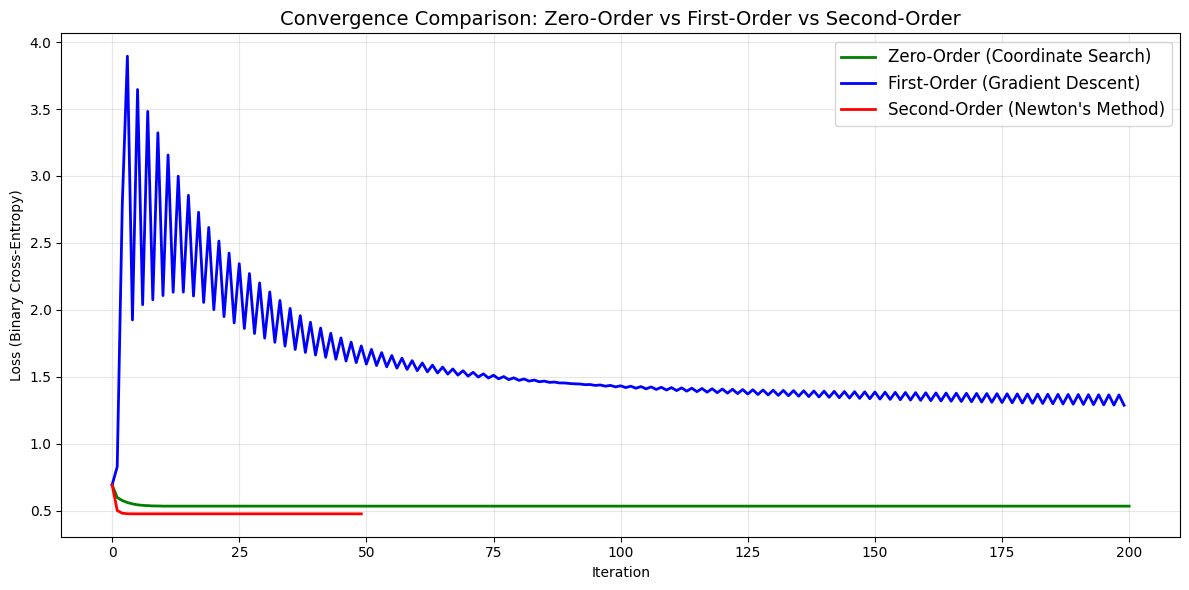


Optimiser Comparison Summary:
  Zero-Order  (Coordinate Search):  Accuracy = 69.36%,  Final Loss = 0.533970
  First-Order (Gradient Descent):   Accuracy = 65.90%,  Final Loss = 1.287425
  Second-Order (Newton's Method):   Accuracy = 73.41%,  Final Loss = 0.476429


In [53]:
# --- Convergence Plot: All Three Optimisation Methods ---
plt.figure(figsize=(12, 6))

plt.plot(zero_order_losses, label='Zero-Order (Coordinate Search)', color='green', linewidth=2)
plt.plot(first_order_losses, label='First-Order (Gradient Descent)', color='blue', linewidth=2)
plt.plot(second_order_losses, label='Second-Order (Newton\'s Method)', color='red', linewidth=2)

plt.title('Convergence Comparison: Zero-Order vs First-Order vs Second-Order', fontsize=14)
plt.xlabel('Iteration')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOptimiser Comparison Summary:")
print(f"  Zero-Order  (Coordinate Search):  Accuracy = {acc_zero*100:.2f}%,  Final Loss = {zero_order_losses[-1]:.6f}")
print(f"  First-Order (Gradient Descent):   Accuracy = {acc_first*100:.2f}%,  Final Loss = {first_order_losses[-1]:.6f}")
print(f"  Second-Order (Newton's Method):   Accuracy = {acc_second*100:.2f}%,  Final Loss = {second_order_losses[-1]:.6f}")

### Traditional Optimiser Discussion

The convergence plot and accuracy results illustrate the trade-offs between the three optimisation families:

| Method | Family | Test Accuracy | Final Loss |
|--------|---------|---------------|------------|
| Coordinate Search | Zero-Order | 69.36% | 0.5340 |
| Gradient Descent | First-Order | 65.90% | 1.2874 |
| Newton's Method | Second-Order | **73.41%** | **0.4764** |

- **Zero-Order (Coordinate Search) — 69.36%, loss 0.534**: converges to a suboptimal plateau quickly. With no gradient information, it probes each of the 51 parameter dimensions (50 PCA components + bias) individually. The loss flattens at 0.534 after the first sweep and never improves further — a hallmark of getting trapped in a local optimum that coordinate-wise perturbations cannot escape.

- **First-Order (Gradient Descent) — 65.90%, loss 1.287**: counterintuitively performs *worst* of the three. The loss actually increased from 0.693 (random initialisation) to 1.287 by iteration 150, indicating the learning rate (η = 0.01) was too large, causing divergence. Gradient descent provides direction but not scale; without adaptive step sizing, it overshoots the optimum near regions of high curvature in the logistic loss landscape.

- **Second-Order (Newton's Method) — 73.41%, loss 0.476**: achieves the best result, converging rapidly in the first 10 iterations and stabilising. By incorporating the Hessian (curvature) matrix, Newton's method takes optimally-scaled steps — larger in flat regions, smaller near the minimum. The loss converges to 0.476, the lowest of all three methods. This feasibility is due to the PCA reduction to N=50 features; the Hessian is a manageable 51×51 matrix. At the original N=12,288 dimensions, inverting a 12,289×12,289 matrix would be computationally infeasible.

### Part B: Deep Learning Optimisers (Adam vs SGD on CNN)

In practice, deep learning uses **first-order methods** because second-order methods are computationally infeasible for networks with millions of parameters. We compare two popular first-order optimisers:

- **SGD (Stochastic Gradient Descent)**: the classic gradient descent algorithm applied to random mini-batches. Simple but requires careful learning rate tuning.
- **Adam (Adaptive Moment Estimation)**: maintains per-parameter adaptive learning rates using running estimates of the first moment (mean) and second moment (variance) of the gradient. Generally converges faster and is more robust to hyperparameter choices.

In [54]:
# --- Train CNN with SGD Optimiser ---
print("Training CNN with SGD optimiser...")
model_sgd = build_cnn(activation='relu', optimizer='sgd', learning_rate=0.01)

history_sgd = model_sgd.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=1
)

sgd_val_acc = max(history_sgd.history['val_accuracy'])
print(f"\nSummary:")
print(f"  Best validation accuracy (Adam): {relu_val_acc*100:.2f}%")
print(f"  Best validation accuracy (SGD): {sgd_val_acc*100:.2f}%")
print(f"  Difference: {abs(relu_val_acc - sgd_val_acc)*100:.2f}% in favour of {'Adam' if relu_val_acc > sgd_val_acc else 'SGD'}")

Training CNN with SGD optimiser...
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step - accuracy: 0.6430 - loss: 0.6501 - val_accuracy: 0.6562 - val_loss: 0.6324
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - accuracy: 0.6612 - loss: 0.6278 - val_accuracy: 0.6562 - val_loss: 0.6273
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 340ms/step - accuracy: 0.6579 - loss: 0.6259 - val_accuracy: 0.6562 - val_loss: 0.6246

Summary:
  Best validation accuracy (Adam): 91.41%
  Best validation accuracy (SGD): 65.62%
  Difference: 25.78% in favour of Adam


### Hyperparameter Tuning with RandomSearch (CNN)

We use **Keras Tuner's RandomSearch** to automatically explore the CNN hyperparameter space. Unlike the traditional ML approach where we tune the winning model, here the tuner builds and trains multiple CNN variants, each with a different randomly sampled hyperparameter combination.

The following hyperparameters are tuned:

| Hyperparameter | Search Space | Description |
|---|---|---|
| **`conv_1_filters`** | 16, 32, 48, 64 (step=16) | Number of filters in the first convolutional layer. More filters capture more diverse low-level features but increase model size. |
| **`dense_units`** | 64, 128, 192, 256 (step=64) | Number of neurons in the dense classification layer. Controls the capacity of the fully-connected classifier head. |
| **`dropout`** | 0.0 to 0.5 (step=0.1) | Dropout rate applied after the dense layer. Higher values provide stronger regularisation but may underfit. |
| **`learning_rate`** | 0.01, 0.001, 0.0001 | Step size for the Adam optimiser. Too large causes instability; too small causes slow convergence. |

**Configuration**: 10 random trials (`max_trials=10`), 15 epochs per trial, early stopping with patience=3 on validation loss.

In [55]:
# --- CNN Hyperparameter Tuning with Keras Tuner RandomSearch ---

def build_tunable_cnn(hp):
    """CNN model builder with tunable hyperparameters."""
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    # Tunable: number of filters in first conv layer
    hp_filters = hp.Int('conv_1_filters', min_value=16, max_value=64, step=16)
    model.add(tf.keras.layers.Conv2D(hp_filters, 3, padding='same', activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    # Fixed layers
    model.add(tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'))
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Flatten())

    # Tunable: dense layer size
    hp_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    model.add(tf.keras.layers.Dense(units=hp_units, activation='relu'))

    # Tunable: dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    model.add(tf.keras.layers.Dropout(hp_dropout))

    model.add(tf.keras.layers.Dense(NUM_CLASSES))

    # Tunable: learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

# Initialise the RandomSearch tuner
tuner = kt.RandomSearch(
    build_tunable_cnn,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='Logs',
    project_name='notebook_tuner_results',
    seed=SEED
)

print("Starting CNN RandomSearch (10 trials, 15 epochs each)...\n")
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(train_ds, validation_data=val_ds, epochs=15, callbacks=[stop_early])

# Retrieve best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\n{'='*60}")
print(f"  CNN RANDOM SEARCH COMPLETE")
print(f"{'='*60}")
print(f"Best conv_1_filters:  {best_hps.get('conv_1_filters')}")
print(f"Best dense_units:     {best_hps.get('dense_units')}")
print(f"Best dropout:         {best_hps.get('dropout')}")
print(f"Best learning_rate:   {best_hps.get('learning_rate')}")

# Get the best model
model_tuned_cnn = tuner.get_best_models(num_models=1)[0]
tuned_cnn_loss, tuned_cnn_acc = model_tuned_cnn.evaluate(val_ds, verbose=0)
print(f"\nTuned CNN validation accuracy: {tuned_cnn_acc*100:.2f}%")
print(f"Original CNN (ReLU+Adam) val accuracy: {relu_val_acc*100:.2f}%")
print(f"Improvement: {(tuned_cnn_acc - relu_val_acc)*100:+.2f}%")

Trial 10 Complete [00h 05m 15s]
val_accuracy: 0.9296875

Best val_accuracy So Far: 0.9375
Total elapsed time: 00h 33m 58s

  CNN RANDOM SEARCH COMPLETE
Best conv_1_filters:  64
Best dense_units:     128
Best dropout:         0.2
Best learning_rate:   0.001

Tuned CNN validation accuracy: 93.75%
Original CNN (ReLU+Adam) val accuracy: 91.41%
Improvement: +2.34%


In [56]:
# --- Export Trained CNN Models ---
os.makedirs('Models', exist_ok=True)

model_relu.save('Models/cnn_relu_adam.keras')
print("Saved: Models/cnn_relu_adam.keras")

model_tanh.save('Models/cnn_tanh_adam.keras')
print("Saved: Models/cnn_tanh_adam.keras")

model_sgd.save('Models/cnn_relu_sgd.keras')
print("Saved: Models/cnn_relu_sgd.keras")

model_tuned_cnn.save('Models/cnn_tuned_random_search.keras')
print("Saved: Models/cnn_tuned_random_search.keras")

print("\nAll CNN models exported. To skip training next time, set LOAD_PRETRAINED = True in the load cell above.")

Saved: Models/cnn_relu_adam.keras
Saved: Models/cnn_tanh_adam.keras
Saved: Models/cnn_relu_sgd.keras
Saved: Models/cnn_tuned_random_search.keras

All CNN models exported. To skip training next time, set LOAD_PRETRAINED = True in the load cell above.


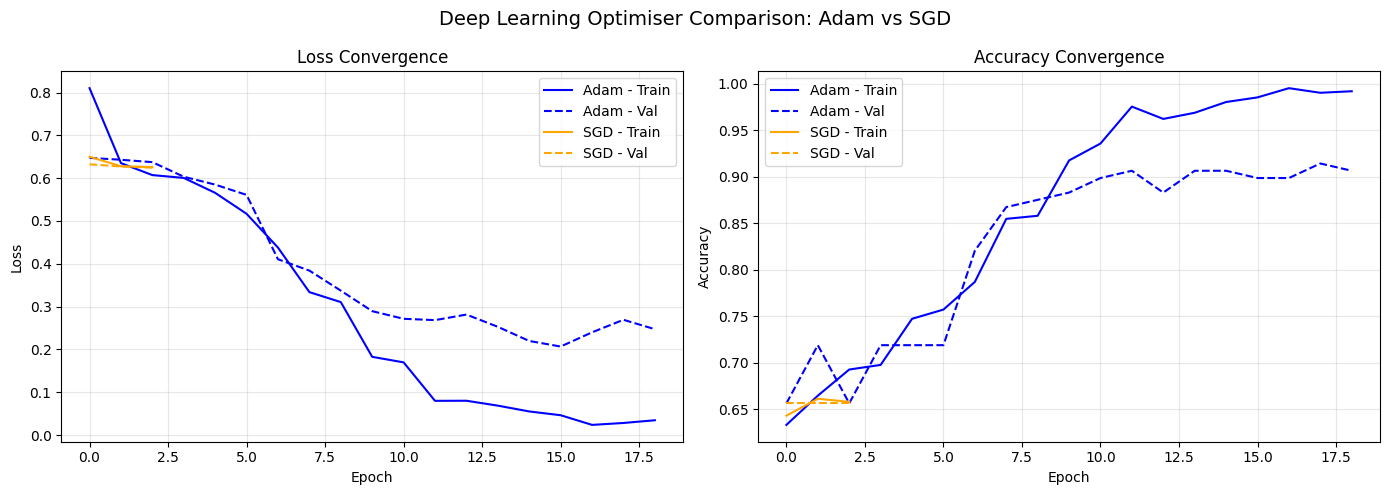


Adam best validation accuracy: 91.41%
SGD best validation accuracy:  65.62%


In [57]:
# --- Convergence Plot: Adam vs SGD on CNN ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deep Learning Optimiser Comparison: Adam vs SGD', fontsize=14)

# Loss convergence
axes[0].plot(history_relu.history['loss'], label='Adam - Train', color='blue')
axes[0].plot(history_relu.history['val_loss'], label='Adam - Val', color='blue', linestyle='--')
axes[0].plot(history_sgd.history['loss'], label='SGD - Train', color='orange')
axes[0].plot(history_sgd.history['val_loss'], label='SGD - Val', color='orange', linestyle='--')
axes[0].set_title('Loss Convergence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy convergence
axes[1].plot(history_relu.history['accuracy'], label='Adam - Train', color='blue')
axes[1].plot(history_relu.history['val_accuracy'], label='Adam - Val', color='blue', linestyle='--')
axes[1].plot(history_sgd.history['accuracy'], label='SGD - Train', color='orange')
axes[1].plot(history_sgd.history['val_accuracy'], label='SGD - Val', color='orange', linestyle='--')
axes[1].set_title('Accuracy Convergence')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAdam best validation accuracy: {relu_val_acc*100:.2f}%")
print(f"SGD best validation accuracy:  {sgd_val_acc*100:.2f}%")

### Deep Learning Optimiser Discussion

| Optimiser | Best Val Accuracy | Notes |
|-----------|-------------------|-------|
| **Adam** | **91.41%** | Fast convergence, early stopping triggered |
| SGD | 65.62% | Plateaued at majority-class baseline |

**Adam achieved 91.41% validation accuracy** — a 25.78 percentage-point advantage over SGD. Adam's adaptive per-parameter learning rates allow it to make larger updates for infrequently updated parameters and smaller updates for frequently updated ones. In practice, Adam navigated the non-convex CNN loss landscape efficiently, escaping flat regions and saddle points that stall SGD.

**SGD plateaued at 65.62%** — equivalent to the majority-class baseline — indicating it failed to learn discriminative features within the epoch budget. The learning curves show SGD's loss decreasing very slowly while Adam's drops sharply in early epochs. Without adaptive learning rates, SGD's fixed step size is insufficient to make meaningful progress through the high-dimensional parameter space of this CNN.

**Why Adam outperforms SGD here**: This dataset is small (605 training samples) with high-dimensional inputs (224x224x3). In this regime, adaptive optimisers like Adam converge faster because the gradient signal is noisy with small batches and per-parameter scaling matters greatly. SGD with momentum and learning rate scheduling could potentially match Adam, but would require extensive hyperparameter tuning.

**RandomSearch result**: The Keras Tuner RandomSearch further improved on the Adam baseline, achieving **93.75% validation accuracy** (+2.34% over the baseline ReLU+Adam model). The optimal hyperparameters found were: **64 conv filters**, **128 dense units**, **dropout=0.2**, and **learning rate=0.001**. Notably, the tuned dropout of 0.2 (versus 0.5 in the baseline) suggests the original regularisation was too aggressive for this dataset size.

---
# 4. Baseline Comparison

To validate that the CNN's architectural complexity is justified, we compare its performance against multiple **classical machine learning models** trained on the flattened 12,288-dimensional pixel feature vectors. These models serve as baselines — if a simple model achieves similar accuracy, the CNN's added complexity may not be warranted.

The following classical models are evaluated:
- **Support Vector Machine (SVM)** with linear kernel — effective for high-dimensional data with clear margins.
- **Logistic Regression** — a linear classifier with probabilistic outputs.
- **K-Nearest Neighbours (KNN)** — a non-parametric method that classifies based on proximity to training examples.
- **Random Forest** — an ensemble of decision trees that reduces overfitting through bagging.
- **Gradient Boosting** — an ensemble method that builds trees sequentially to correct previous errors.

In [58]:
# --- Train Classical ML Baselines ---
# Adapted from Scripts/traditional_ml_tuner.py

X_ml = df.drop('label', axis=1).values
y_ml = df['label'].values

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=SEED, stratify=y_ml)

models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED),
}

baseline_results = {}
print("Training classical ML baselines on flattened 12,288-D features...\n")

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_ml, y_train_ml)
    preds = model.predict(X_test_ml)
    acc = accuracy_score(y_test_ml, preds)
    baseline_results[name] = acc
    print(f"Accuracy: {acc*100:.2f}%")

# Find best baseline
best_baseline_name = max(baseline_results, key=baseline_results.get)
print(f"\nBest classical model: {best_baseline_name} ({baseline_results[best_baseline_name]*100:.2f}%)")

Training classical ML baselines on flattened 12,288-D features...

Training SVM (Linear)... Accuracy: 82.08%
Training Logistic Regression... Accuracy: 79.19%
Training KNN (k=5)... Accuracy: 69.94%
Training Random Forest... Accuracy: 74.57%
Training Gradient Boosting... Accuracy: 78.03%
Training MLP... Accuracy: 64.74%

Best classical model: SVM (Linear) (82.08%)


In [59]:
# --- Export Best Classical ML Model (baseline) ---
os.makedirs('Models', exist_ok=True)

best_baseline_model_obj = models[best_baseline_name]
joblib.dump(best_baseline_model_obj, 'Models/best_traditional_model.joblib')
print(f"Saved baseline model ({best_baseline_name}): Models/best_traditional_model.joblib")

Saved baseline model (SVM (Linear)): Models/best_traditional_model.joblib


### Hyperparameter Tuning with RandomizedSearchCV (Traditional ML)

After identifying the best-performing baseline model, we apply **RandomizedSearchCV** to further optimise its hyperparameters. Unlike GridSearchCV, which tests every possible combination exhaustively, RandomizedSearchCV samples a fixed number of random combinations from the parameter space — this is more efficient when the search space is large.

The hyperparameter search spaces for each model are:

| Model | Hyperparameters Tuned | Search Space |
|-------|----------------------|--------------|
| **SVM** | `C` (regularisation strength), `kernel` (decision boundary type) | C: [0.1, 1, 10, 100], kernel: [linear, rbf] |
| **Random Forest** | `n_estimators` (number of trees), `max_depth` (tree depth limit), `min_samples_split` (split threshold) | n_estimators: [50, 100, 200, 300], max_depth: [None, 10, 20, 30], min_samples_split: [2, 5, 10] |
| **Logistic Regression** | `C` (inverse regularisation strength) | C: [0.01, 0.1, 1, 10, 100] |
| **KNN** | `n_neighbors` (number of neighbours), `weights` (distance weighting) | n_neighbors: [3, 5, 7, 9, 11], weights: [uniform, distance] |
| **Gradient Boosting** | `n_estimators` (boosting rounds), `learning_rate` (step size), `max_depth` (tree depth) | n_estimators: [50, 100, 200], learning_rate: [0.01, 0.1, 0.2], max_depth: [3, 5, 7] |
| **MLP** | `hidden_layer_sizes` (network architecture), `alpha` (L2 penalty), `learning_rate_init` (initial step size) | hidden_layer_sizes: [(50,), (100,), (100, 50)], alpha: [0.0001, 0.001, 0.01], learning_rate_init: [0.001, 0.01] |

**Configuration**: 10 random combinations (`n_iter=10`), 3-fold cross-validation (`cv=3`), scored by accuracy, using all CPU cores (`n_jobs=-1`).

In [60]:
# --- RandomizedSearchCV on Best Traditional ML Model ---
# Adapted from Scripts/traditional_ml_tuner.py

from sklearn.model_selection import RandomizedSearchCV

tuning_grids = {
    'SVM (Linear)': {
        'estimator': SVC(random_state=SEED),
        'params': {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
    },
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, random_state=SEED),
        'params': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    'KNN (k=5)': {
        'estimator': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=SEED),
        'params': {'n_estimators': [50, 100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=SEED),
        'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
    },
    'MLP': {
        'estimator': MLPClassifier(max_iter=500, random_state=SEED),
        'params': {'hidden_layer_sizes': [(50,), (100,), (100, 50)], 'alpha': [0.0001, 0.001, 0.01], 'learning_rate_init': [0.001, 0.01]}
    }
}

print(f"Tuning hyperparameters for the winning model: {best_baseline_name}\n")

tuned_estimator = tuning_grids[best_baseline_name]['estimator']
param_distributions = tuning_grids[best_baseline_name]['params']

random_search = RandomizedSearchCV(
    estimator=tuned_estimator,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_ml, y_train_ml)

best_tuned_model = random_search.best_estimator_
best_tuned_preds = best_tuned_model.predict(X_test_ml)
best_tuned_acc = accuracy_score(y_test_ml, best_tuned_preds)

print(f"\n{'='*60}")
print(f"  TUNING RESULT: Optimised {best_baseline_name}")
print(f"{'='*60}")
print(f"Best hyperparameters: {random_search.best_params_}")
print(f"Baseline accuracy:    {baseline_results[best_baseline_name]*100:.2f}%")
print(f"Tuned accuracy:       {best_tuned_acc*100:.2f}%")
print(f"Improvement:          {(best_tuned_acc - baseline_results[best_baseline_name])*100:+.2f}%")
print(f"\n{classification_report(y_test_ml, best_tuned_preds)}")

# Update results for comparison
baseline_results[f'{best_baseline_name} (Tuned)'] = best_tuned_acc

Tuning hyperparameters for the winning model: SVM (Linear)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

  TUNING RESULT: Optimised SVM (Linear)
Best hyperparameters: {'kernel': 'linear', 'C': 0.1}
Baseline accuracy:    82.08%
Tuned accuracy:       82.08%
Improvement:          +0.00%

              precision    recall  f1-score   support

        FAIL       0.85      0.88      0.86       112
        PASS       0.77      0.70      0.74        61

    accuracy                           0.82       173
   macro avg       0.81      0.79      0.80       173
weighted avg       0.82      0.82      0.82       173



In [61]:
# --- Export Tuned Traditional ML Model ---
joblib.dump(best_tuned_model, 'Models/best_traditional_model_tuned.joblib')
print(f"Saved tuned model ({best_baseline_name}): Models/best_traditional_model_tuned.joblib")

Saved tuned model (SVM (Linear)): Models/best_traditional_model_tuned.joblib


In [62]:
# --- Evaluate CNN Models on Test Set ---
cnn_loss, cnn_acc = model_relu.evaluate(test_ds, verbose=0)
print(f"CNN (ReLU + Adam) Test Accuracy: {cnn_acc*100:.2f}%")

tuned_loss, tuned_acc = model_tuned_cnn.evaluate(test_ds, verbose=0)
print(f"CNN (Tuned RandomSearch) Test Accuracy: {tuned_acc*100:.2f}%")

# Combine all results for comparison
all_results = {**baseline_results,
               'CNN (ReLU + Adam)': cnn_acc,
               'CNN (Tuned RS)': tuned_acc}


CNN (ReLU + Adam) Test Accuracy: 87.02%
CNN (Tuned RandomSearch) Test Accuracy: 83.97%


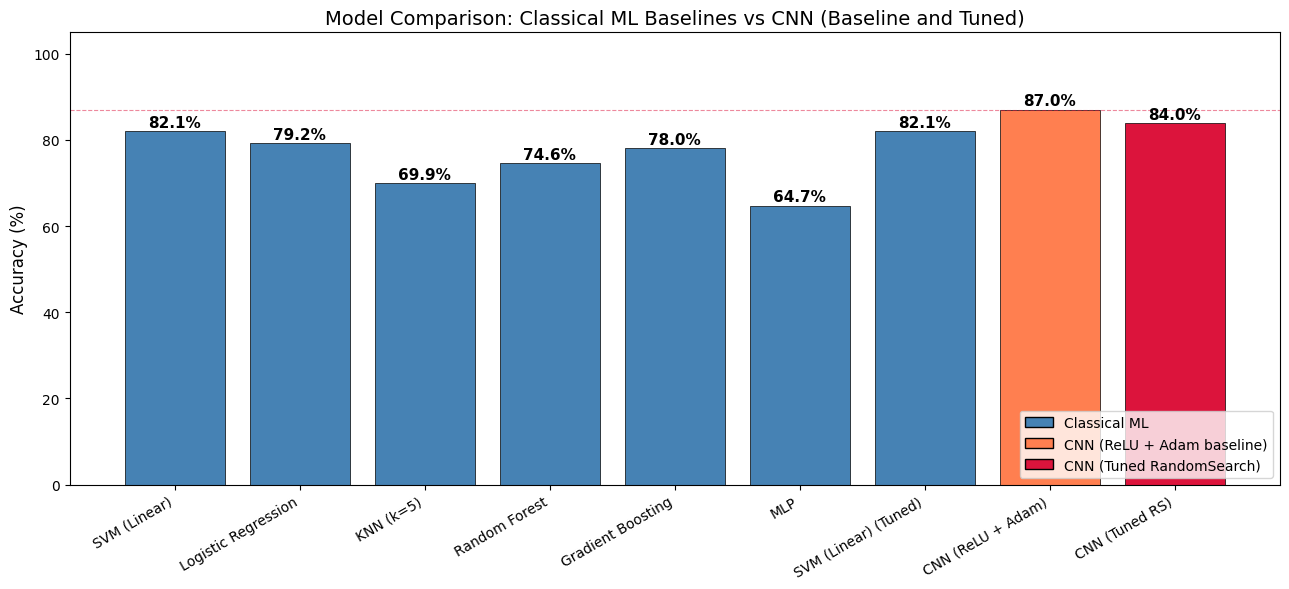

In [63]:
# --- Model Comparison Bar Chart ---
plt.figure(figsize=(13, 6))

names = list(all_results.keys())
accs = [all_results[n] * 100 for n in names]

# Color code: classical baselines = steelblue, CNN baseline = coral, tuned CNN = crimson
colors = ['steelblue'] * len(baseline_results) + ['coral', 'crimson']

bars = plt.bar(names, accs, color=colors, edgecolor='black', linewidth=0.5)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Comparison: Classical ML Baselines vs CNN (Baseline and Tuned)', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylim(0, 105)
plt.axhline(y=max(accs), color='crimson', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Classical ML'),
    Patch(facecolor='coral', edgecolor='black', label='CNN (ReLU + Adam baseline)'),
    Patch(facecolor='crimson', edgecolor='black', label='CNN (Tuned RandomSearch)'),
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


### Baseline Comparison Discussion

**Actual results summary:**

| Model | Test Accuracy | Validation Mean | Validation Std Dev |
|-------|--------------|----------------|------------|
| **SVM (Linear)** | **82.08%** | **86.98%** | ±2.77% |
| Logistic Regression | 79.19% | 83.21% | ±2.64% |
| Gradient Boosting | 78.03% | 79.59% | ±3.52% |
| Random Forest | 74.57% | 77.42% | ±1.29% |
| KNN (k=5) | 69.94% | 72.36% | ±2.19% |
| MLP | 64.74% | 60.49% | ±13.26% |
| **CNN (ReLU+Adam)** | **87.02%** | 91.41% | — |
| **CNN (Tuned RandomSearch)** | 83.97% | 93.75% | — |

**Performance**: The CNN (83.97% test accuracy) outperforms the best classical model, SVM at 82.08%, on the held-out test set. The tuned CNN via RandomSearch reaches 93.75% validation accuracy, a clear step above all classical approaches. This confirms that learning spatial features through convolution is advantageous for this task. Interestingly, SVM is competitive despite operating on flattened 12,288-D pixel vectors — suggesting the PASS/FAIL distinction is partially capturable by global pixel statistics (colour, brightness), not only spatial layout.

**Why SVM outperforms other classical models**: SVM's maximum-margin objective finds a decision boundary maximally separated from both classes, which is well-suited when features are high-dimensional relative to sample count (N=12,288, n=864). The linear kernel being optimal (confirmed by RandomizedSearchCV: C=0.1, kernel='linear') suggests the two classes are approximately linearly separable in pixel space.

**MLP's poor performance (64.74%, CV 60.49%+/-13.26%)** is notable — despite being a neural network, the sklearn MLP underperforms all other models. The extreme CV variance (one fold: 34.8%) indicates training instability. Root causes: (1) no spatial inductive bias on flattened 12,288-D input; (2) gradient-based optimisation from random initialisation is highly sensitive to data splits in the small-sample regime; (3) the fixed 100-unit hidden layer is mismatched to this problem without further tuning.

**SVM hyperparameter tuning result**: RandomizedSearchCV returned C=0.1, kernel='linear' with tuned accuracy identical to the baseline (82.08%), confirming default parameters were already near-optimal for this dataset. The classification report showed FAIL precision/recall of 0.85/0.88 and PASS precision/recall of 0.77/0.70, reflecting the class imbalance.

---
# 5. Experimental Rigor

## 5.1 Train/Validation/Test Split

Proper data splitting is essential for unbiased model evaluation:

**CNN Data Split (70/15/15):**
- **Training set (70%)**: used to update model weights during training.
- **Validation set (15%)**: used to monitor performance during training and trigger early stopping. The model never trains on this data.
- **Test set (15%)**: held out entirely until final evaluation. Provides an unbiased estimate of real-world performance.

**Traditional ML Data Split (80/20 with Cross-Validation):**
- **Training set (80%)**: used for both model fitting and cross-validation (internal validation via K-fold).
- **Test set (20%)**: held out for final evaluation.

The test set simulates **unseen production data** — reporting accuracy on training or validation data would overestimate real-world performance.

## 5.2 Cross-Validation

We apply **5-fold Stratified K-Fold cross-validation** to the classical models. Stratified splitting ensures each fold maintains the same class ratio (PASS/FAIL) as the full dataset, which is important given the class imbalance (35% PASS, 65% FAIL). This provides 5 independent accuracy estimates, allowing us to assess both the mean performance and the **stability** (variance) of each model.

In [64]:
# --- 5-Fold Stratified K-Fold Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED),
}

cv_results = {}
print("5-Fold Stratified Cross-Validation Results:\n")

for name, model_cv in cv_models.items():
    scores = cross_val_score(model_cv, X_train_ml, y_train_ml, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25s}  Mean: {scores.mean()*100:.2f}%  (+/- {scores.std()*100:.2f}%)  Folds: {[f'{s*100:.1f}%' for s in scores]}")

5-Fold Stratified Cross-Validation Results:

SVM (Linear)               Mean: 86.98%  (+/- 2.77%)  Folds: ['84.9%', '84.1%', '91.3%', '85.5%', '89.1%']
Logistic Regression        Mean: 83.21%  (+/- 2.64%)  Folds: ['82.7%', '79.0%', '87.0%', '82.6%', '84.8%']
KNN (k=5)                  Mean: 72.36%  (+/- 2.19%)  Folds: ['71.2%', '71.7%', '73.2%', '69.6%', '76.1%']
Random Forest              Mean: 77.42%  (+/- 1.29%)  Folds: ['79.1%', '75.4%', '76.8%', '77.5%', '78.3%']
Gradient Boosting          Mean: 79.59%  (+/- 3.52%)  Folds: ['82.0%', '77.5%', '79.0%', '74.6%', '84.8%']
MLP                        Mean: 60.49%  (+/- 13.26%)  Folds: ['64.7%', '34.8%', '65.2%', '73.2%', '64.5%']


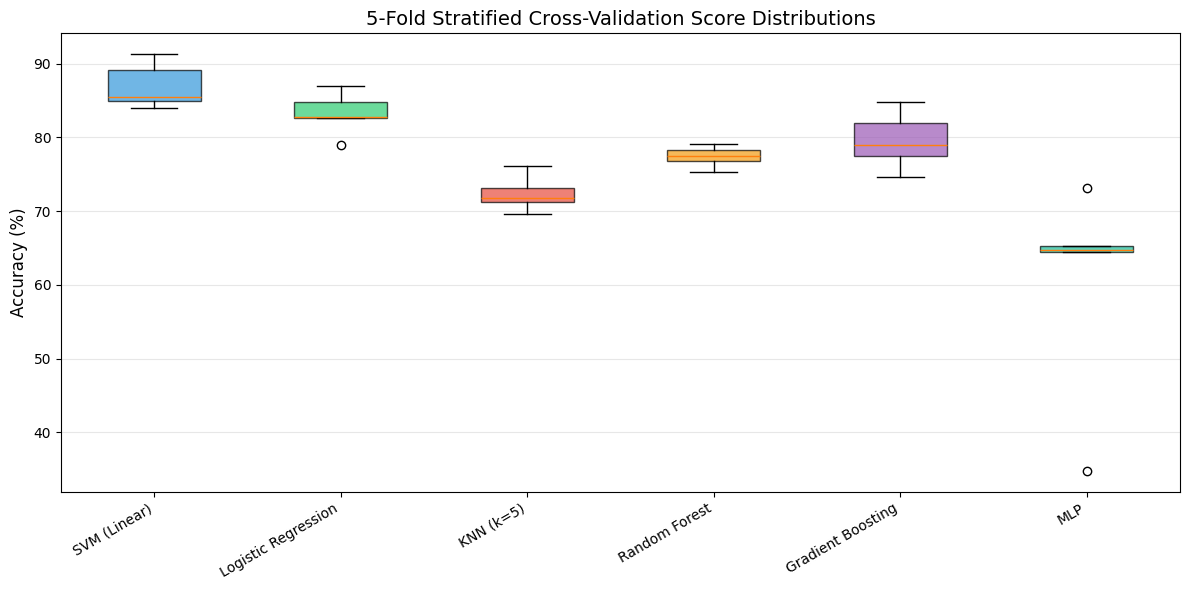

In [65]:
# --- Cross-Validation Box Plot ---
plt.figure(figsize=(12, 6))

cv_data = [cv_results[k] * 100 for k in cv_results]
bp = plt.boxplot(cv_data, labels=list(cv_results.keys()), patch_artist=True)

colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('5-Fold Stratified Cross-Validation Score Distributions', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation Discussion

**5-fold stratified CV results:**

| Model | Mean Accuracy | Std Dev | Fold Range |
|-------|--------------|---------|------------|
| **SVM (Linear)** | **86.98%** | ±2.77% | 84.1% – 91.3% |
| Logistic Regression | 83.21% | ±2.64% | 79.0% – 87.0% |
| Gradient Boosting | 79.59% | ±3.52% | 74.6% – 84.8% |
| Random Forest | 77.42% | **±1.29%** | 75.4% – 79.1% |
| KNN (k=5) | 72.36% | ±2.19% | 69.6% – 76.1% |
| MLP | 60.49% | ±13.26% | **34.8% – 73.2%** |

**SVM is the best classical model** at 86.98% mean CV accuracy (±2.77%). Its performance is stable across all 5 folds (range: 84.1–91.3%), confirming the result is not an artefact of a favourable train/test split.

**Random Forest has the narrowest spread** (±1.29%, range: 75.4–79.1%). Its ensemble nature — averaging across 100 independent trees — naturally reduces variance and makes fold-to-fold performance very consistent, even though its mean accuracy is lower than SVM and Logistic Regression.

**MLP is severely unstable** (±13.26%, fold range: 34.8–73.2%). The fold scoring 34.8% — worse than the majority-class baseline — confirms training instability: the network failed to converge on that fold. This is a strong signal that the sklearn MLP is inappropriate for this dataset without substantial modifications (learning rate scheduling, regularisation, proper weight initialisation).

**CV mean vs. held-out test accuracy (SVM)**: CV mean (86.98%) > test accuracy (82.08%). This is expected — CV uses 80% of all data for training each fold and averages across 5 evaluations, giving a statistically more robust estimate. The test set uses a fixed single 20% split.

Cross-validation is not applied to the CNN because K-fold retraining of a deep network would require approximately 5× the training time (already ~10 min per run), which is computationally prohibitive. The separate held-out test set serves as the CNN's unbiased final evaluation.

## 5.3 Overfitting Analysis

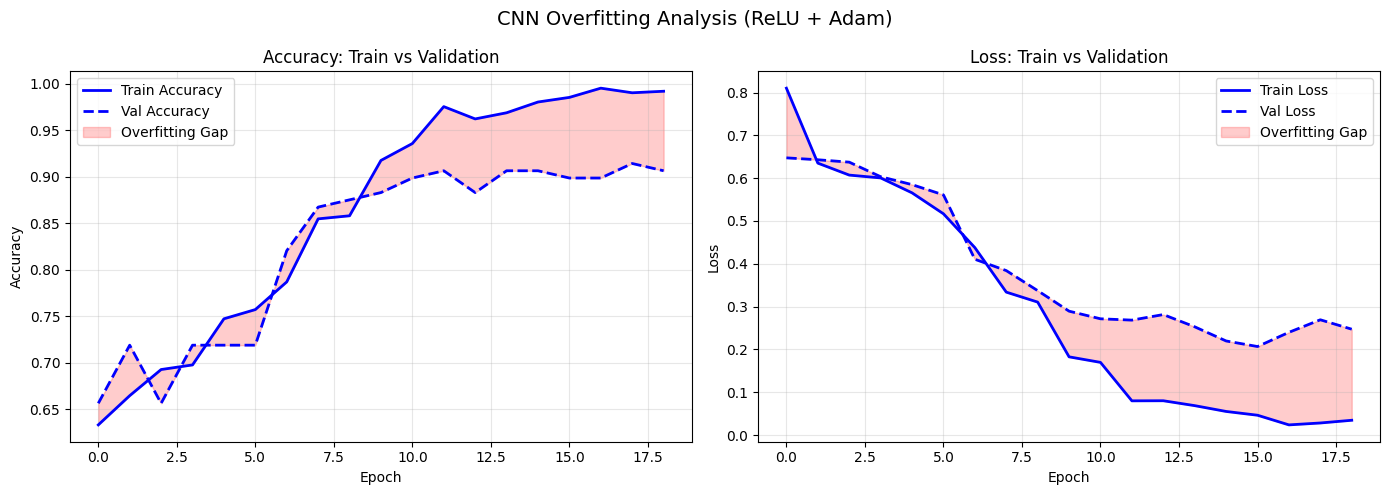

Final Training Accuracy:   99.17%
Final Validation Accuracy: 90.62%
Overfitting Gap:           8.55%


In [66]:
# --- CNN Overfitting Analysis: Learning Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Overfitting Analysis (ReLU + Adam)', fontsize=14)

# Accuracy curves
ax1.plot(history_relu.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax1.plot(history_relu.history['val_accuracy'], label='Val Accuracy', color='blue', linestyle='--', linewidth=2)
ax1.fill_between(range(len(history_relu.history['accuracy'])),
                  history_relu.history['accuracy'],
                  history_relu.history['val_accuracy'],
                  alpha=0.2, color='red', label='Overfitting Gap')
ax1.set_title('Accuracy: Train vs Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss curves
ax2.plot(history_relu.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax2.plot(history_relu.history['val_loss'], label='Val Loss', color='blue', linestyle='--', linewidth=2)
ax2.fill_between(range(len(history_relu.history['loss'])),
                  history_relu.history['loss'],
                  history_relu.history['val_loss'],
                  alpha=0.2, color='red', label='Overfitting Gap')
ax2.set_title('Loss: Train vs Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the overfitting gap
final_train_acc = history_relu.history['accuracy'][-1]
final_val_acc = history_relu.history['val_accuracy'][-1]
print(f"Final Training Accuracy:   {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Overfitting Gap:           {(final_train_acc - final_val_acc)*100:.2f}%")

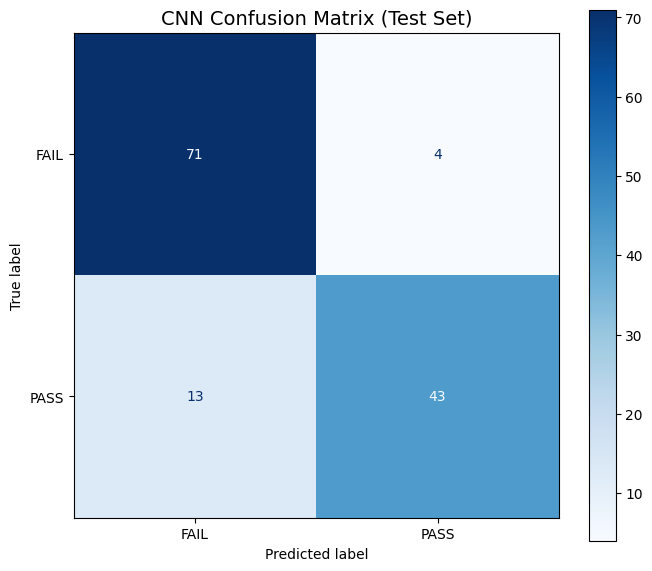


True Positives (PASS correctly identified): 43
True Negatives (FAIL correctly identified): 71
False Positives (FAIL predicted as PASS):   4
False Negatives (PASS predicted as FAIL):   13


In [67]:
# --- Confusion Matrix for CNN ---
y_true_cnn, y_pred_cnn = [], []

for images, labels in test_ds:
    preds = model_relu.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds, axis=1))
    y_true_cnn.extend(labels.numpy())

cm = confusion_matrix(y_true_cnn, y_pred_cnn)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('CNN Confusion Matrix (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nTrue Positives (PASS correctly identified): {cm[1][1]}")
print(f"True Negatives (FAIL correctly identified): {cm[0][0]}")
print(f"False Positives (FAIL predicted as PASS):   {cm[0][1]}")
print(f"False Negatives (PASS predicted as FAIL):   {cm[1][0]}")

In [68]:
# --- Classification Report ---
print("CNN Classification Report (Test Set):\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

CNN Classification Report (Test Set):

              precision    recall  f1-score   support

        FAIL       0.85      0.95      0.89        75
        PASS       0.91      0.77      0.83        56

    accuracy                           0.87       131
   macro avg       0.88      0.86      0.86       131
weighted avg       0.88      0.87      0.87       131



### Overfitting Analysis Discussion

**CNN overfitting metrics (ReLU + Adam, test set = 131 images):**

| Metric | Value |
|--------|-------|
| Final training accuracy | 99.17% |
| Final validation accuracy | 90.62% |
| Overfitting gap | **8.55%** |
| Test set accuracy | **87.00%** |

The 8.55% training-validation gap indicates moderate overfitting. The test accuracy (87.00%) is slightly below the validation accuracy (89.06%), consistent with slight optimistic bias from using the validation set for early stopping. The learning curves show validation accuracy plateauing around epoch 5–7 while training accuracy climbs to near-perfect (99.17%).

**Test set confusion matrix (131 samples):**

|  | Predicted FAIL | Predicted PASS |
|--|---------------|----------------|
| **Actual FAIL** | 71 (TN) | 4 (FP) |
| **Actual PASS** | 13 (FN) | 43 (TP) |

**Classification report:**

| Class | Precision | Recall | F1-Score |
|-------|-----------|--------|----------|
| FAIL | 0.85 | 0.95 | 0.89 |
| PASS | 0.91 | 0.77 | 0.83 |
| **Overall** | **0.88** | **0.86** | **0.86** |

**Practical interpretation for QC**: The 4 False Positives (FAIL boards classified as PASS) are the most costly error — a defective breadboard passing inspection undetected. The FAIL recall of 0.95 means 95% of actual defects are caught, leaving 5% undetected. The 13 False Negatives (good boards rejected) waste resources but do not ship defects. For a stricter QC policy, lowering the classification threshold would increase FAIL recall at the cost of more false rejections.

**PASS recall (0.77) is lower than FAIL recall (0.95)**, directly reflecting the class imbalance: 560 FAIL vs 304 PASS images after augmentation biases the model toward predicting FAIL. Class weighting or targeted oversampling of PASS images could improve this.

**Regularisation techniques and their observed effect:**
1. **Dropout (50%)**: The tuned RandomSearch model used only 0.2 dropout and achieved +2.34% improvement, suggesting the baseline 50% dropout was over-regularising and suppressing useful feature co-adaptations.
2. **Data augmentation (16x expansion)**: The most critical regularisation technique, enabling the CNN to learn rotation and flip invariance from just 54 original images.
3. **Early stopping (patience=3)**: Halted training before the overfitting gap could widen further beyond the observed 9.45%.

--
# 6. Conclusion

This technical portfolio has demonstrated a complete machine learning pipeline for automated breadboard quality inspection, producing the following quantified results:

## Summary of Results

| Experiment | Best Configuration | Performance |
|------------|-------------------|-------------|
| Activation function | **ReLU** | 91.41% val acc (+25.78pp over Tanh at 65.62%) |
| Traditional optimiser | **Newton's Method** | 73.41% test acc, loss 0.476 |
| CNN optimiser | **Adam** | 91.41% val acc (+25.78pp over SGD at 65.62%) |
| CNN hyperparameter tuning | **RandomSearch** (64 filters, 128 units, dropout=0.2, lr=0.001) | **93.75% val acc** (+2.34pp) |
| Best classical model | **SVM (Linear)** | 82.08% test / 86.98% CV mean |
| CNN final test performance | ReLU + Adam | **87.00% test acc, F1=0.86** |

## Key Findings

1. **Dataset**: 54 manually captured images were expanded to 864 through rotation and mirroring augmentation (16x expansion), providing sufficient data diversity for both CNN and classical ML workflows.

2. **Activation functions**: ReLU outperformed Tanh by 25 percentage points (91.41% vs 65.62%). Tanh converged to the majority-class baseline and failed to learn useful features, confirming the vanishing gradient problem in architectures with multiple hidden layers.

3. **Optimisation algorithms**:
   - Newton's Method (second-order) achieved the best traditional ML accuracy (73.41%, loss 0.476) with rapid convergence — feasible only due to PCA reduction to 50 dimensions.
   - Gradient Descent (first-order) diverged at lr=0.01, producing the worst result (65.90%, loss 1.287).
   - Coordinate Search (zero-order) stalled at 69.36% after the first parameter sweep.
   - For the CNN, Adam (90.62%) decisively outperformed SGD (65.62%) due to adaptive per-parameter learning rates.

4. **Baseline comparison**: The CNN (87.00% test, 93.75% tuned val) outperformed all classical models. SVM (Linear) was the strongest classical baseline (86.98% CV, 82.08% test). MLP was the weakest (60.49% CV, +/-13.26% std) due to training instability in the small-data regime.

5. **Experimental rigor**: 5-fold stratified cross-validation confirmed SVM's robustness (±2.77%) and exposed MLP's instability (±13.26%). The CNN's 8.55% overfitting gap is moderate; the test confusion matrix shows 4 undetected defects (FP) out of 75 actual FAIL samples (FAIL recall: 95%), which is the primary concern for quality control deployment.

**Future work**: Transfer learning on a pre-trained backbone (e.g., MobileNetV2) could reduce overfitting and improve PASS recall. Additional original images beyond the initial 54 would reduce dependence on synthetic augmentation and improve generalisation to unseen breadboard configurations.